In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/azid_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [3]:
df.response.value_counts()

0    706
1    177
2     54
3     23
Name: response, dtype: int64

In [4]:
# number of sequences
Nseq = len(df)
Nseq

960

In [5]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [6]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

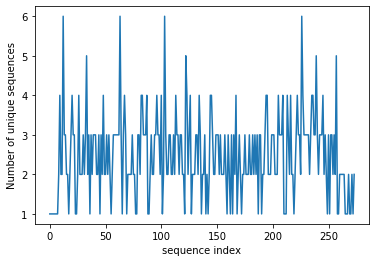

In [7]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [8]:
len(df.sequence.unique())

905

In [9]:
len(df)

960

In [10]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

33


,sequence,count,response,first_stop
14,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1425,3,122
8,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,200,1,84
25,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,57,1,84
96,MQHTYPAQLMRFGTAARAEHMTIAAATHALDADEADAIVMDIVPDG...,30,1,167
103,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,28,1,91
104,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,28,1,167
121,MQHTYPAQLMRFGTAARAEHKTIAAAIHALDADEADAIVMDIVPDG...,27,1,170
145,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVKDTVPDG...,24,1,167
160,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,1,214
31,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,24,0,160


In [11]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1185,1,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,515,0,273


In [12]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [13]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16082,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,12035,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9704,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4234,2


In [14]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,647
1,157
2,54
3,14


In [15]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2


In [16]:
# drop the start and stop codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT)-1))

## Ordinal regression

In [17]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

import mord
from mord import LogisticAT

In [18]:
y = df_unique.response.to_numpy()
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now

X = enc.fit_transform(design_cols)
print(X.shape)
X

(872, 656)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [19]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)

model.fit(X, y)
model.score(X, y)

-0.143348623853211

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

In [21]:
pipeline = Pipeline([('vt', VarianceThreshold()), ('scaler', StandardScaler()), ('model', model)])

In [22]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=pipeline, param_grid=dict(model__alpha=alphas), 
                       cv=StratifiedKFold(5), n_jobs=5, iid='deprecated')
grid_cv.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             error_score='raise-deprecating',
             estimator=Pipeline(memory=None,
                                steps=[('vt', VarianceThreshold(threshold=0.0)),
                                       ('scaler',
                                        StandardScaler(copy=True,
                                                       with_mean=True,
                                                       with_std=True)),
                                       ('model',
                                        LogisticAT(alpha=1.0, max_iter=1000,
                                                   verbose=0))],
                                verbose=False),
             iid='deprecated', n_jobs=5,
             param_grid={'model__alpha': array([1.00000000e-06, 7.74263683e-06, 5.99484250e-05, 4.64158883e-04,
       3.59381366e-03, 2.78255940e-02, 2.15443469e-01, 1.66810054e+00,
       1.29154967e+01, 1.00

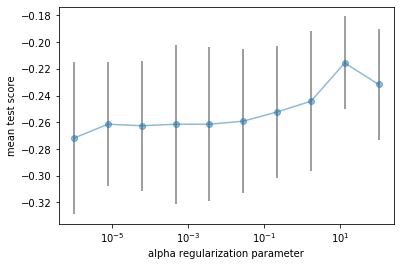

In [23]:
plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score");

In [24]:
# regularization parameter picked by CV
grid_cv.best_params_

{'model__alpha': 12.915496650148826}

In [25]:
grid_cv.best_score_

-0.21559633027522937

In [26]:
best_model = grid_cv.best_estimator_['model']

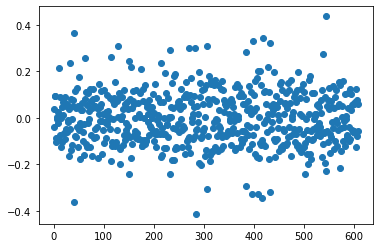

In [27]:
grid_cv.best_estimator_.fit(X, y)
best_coefs = grid_cv.best_estimator_['model'].coef_

plt.plot(best_coefs, 'o')

In [28]:
vt = grid_cv.best_estimator_.named_steps['vt']
feature_names_after_threshold = enc.get_feature_names()[vt.get_support()]

In [29]:
best_results = pd.DataFrame({'feature':feature_names_after_threshold, 'coef':best_coefs})
# extract the Residue index and the AA mutation 
best_results[["idx", "aa_mut"]] = \
    best_results.feature.str.extractall(r"x([0-9]+)_([A-Z])").reset_index(drop=True)
best_results["idx"] = best_results.idx.astype(int)

In [30]:
descending_sort_results = best_results.sort_values('coef', ascending=False)
descending_sort_results.head(10)

,feature,coef,idx,aa_mut
543,x237_Q,0.436565,237,Q
41,x24_T,0.363462,24,T
417,x190_S,0.344590,190,S
397,x180_P,0.328705,180,P
431,x195_D,0.319409,195,D
129,x62_E,0.310071,62,E
306,x136_A,0.306836,136,A
283,x125_I,0.298532,125,I
270,x121_I,0.298522,121,I
232,x106_C,0.291693,106,C


In [31]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()

In [32]:
print(descending_sort_results.iloc[0])
show_design_response(descending_sort_results.iloc[0].idx)

feature      x237_Q
coef       0.436565
idx             237
aa_mut            Q
Name: 543, dtype: object


aa  response
L   0           645
    1           157
    2            54
    3            11
Q   3             3
V   0             2
dtype: int64

In [33]:
print(descending_sort_results.iloc[1])
show_design_response(descending_sort_results.iloc[1].idx)

feature       x24_T
coef       0.363462
idx              24
aa_mut            T
Name: 41, dtype: object


aa  response
A   0           647
    1           157
    2            54
    3            10
T   3             4
dtype: int64

In [34]:
ascending_sort_results = best_results.sort_values('coef', ascending=True)
ascending_sort_results.head(10)

,feature,coef,idx,aa_mut
285,x125_V,-0.413846,125,V
40,x24_A,-0.363462,24,A
416,x190_G,-0.344590,190,G
408,x185_T,-0.329750,185,T
396,x180_L,-0.328705,180,L
432,x195_E,-0.319409,195,E
307,x136_T,-0.306836,136,T
383,x174_H,-0.294050,174,H
502,x225_E,-0.243547,225,E
150,x71_A,-0.242269,71,A


In [35]:
print(ascending_sort_results.iloc[0])
show_design_response(ascending_sort_results.iloc[0].idx)

feature      x125_V
coef      -0.413846
idx             125
aa_mut            V
Name: 285, dtype: object


aa  response
F   0             6
I   0           636
    1           157
    2            54
    3            14
T   0             2
V   0             3
dtype: int64

In [36]:
print(ascending_sort_results.iloc[1])
show_design_response(ascending_sort_results.iloc[1].idx)

feature       x24_A
coef      -0.363462
idx              24
aa_mut            A
Name: 40, dtype: object


aa  response
A   0           647
    1           157
    2            54
    3            10
T   3             4
dtype: int64

In [37]:
# FIXME: save to excel here
pd.set_option('display.max_rows', 10)
best_results

,feature,coef,idx,aa_mut
0,x7_L,0.039084,7,L
1,x7_P,-0.039084,7,P
2,x8_I,0.093314,8,I
3,x8_M,0.091934,8,M
4,x8_T,-0.086421,8,T
...,...,...,...,...
604,x263_T,0.124684,263,T
605,x267_C,-0.078256,267,C
606,x267_W,0.078256,267,W
607,x270_F,0.058681,270,F


## Model comparison


Loosely based on someone's blog post [https://rikunert.com/ordinal_rating](https://rikunert.com/ordinal_rating)

In [38]:
best_alpha = best_model.get_params()['alpha']

In [39]:
# instantiate models
model_linear = Ridge()
model_1vR = LogisticRegression(multi_class='ovr', fit_intercept=False,
    class_weight='balanced')
model_multi = LogisticRegression(multi_class='multinomial', fit_intercept=False,
    solver='lbfgs',
    class_weight='balanced', C = 0.001 )
model_ordinal = LogisticAT(alpha=0)
model_ordinal_best = LogisticAT(alpha=best_alpha)
folds = StratifiedKFold(5)
MAE = make_scorer(mean_absolute_error)


import sklearn.base
class PredictZero(sklearn.base.BaseEstimator):
    """This class predicts zero for every input"""
    def __init__(self):
        self.alpha = 0
    
    def fit(self, *args, **kwargs):
        return self
    
    def predict(self, X):
        return np.zeros(X.shape[0], dtype=np.int)
    
model_zero = PredictZero()

In [40]:
model_dict = {"zero":model_zero, "ridge":model_linear, "lr1vR":model_1vR, "multinomial":model_multi,
             "ordinal":model_ordinal, "ordinal_best":model_ordinal_best}

In [41]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


x = [cross_val_score(m, X, y, cv=folds, scoring=MAE) for k, m in model_dict.items()]
mae_test_results = pd.DataFrame(x, index=model_dict.keys())
mae_test_results

,0,1,2,3,4
zero,0.357955,0.357955,0.356322,0.356322,0.331395
ridge,0.354464,0.332994,0.319232,0.377963,0.388832
lr1vR,0.267045,0.125000,0.172414,0.281609,0.244186
multinomial,1.346591,0.505682,0.833333,0.729885,0.627907
ordinal,0.215909,0.244318,0.218391,0.419540,0.383721
ordinal_best,0.340909,0.352273,0.350575,0.362069,0.319767


In [42]:
# Average Mean Absolute Errors
mae_test_results.mean(axis=1).to_frame().T

,zero,ridge,lr1vR,multinomial,ordinal,ordinal_best
0,0.35199,0.354697,0.218051,0.80868,0.296376,0.345119


In [43]:
def acc_fun(target_true, target_fit):
    target_fit = np.round(target_fit)
    target_fit.astype('int')
    return accuracy_score(target_true, target_fit)

acc = make_scorer(acc_fun)

In [44]:
x = [cross_val_score(m, X, y, cv=folds, scoring=acc) for k, m in model_dict.items()]
acc_test_results = pd.DataFrame(x, index=model_dict.keys())
acc_test_results

,0,1,2,3,4
zero,0.738636,0.738636,0.741379,0.741379,0.750000
ridge,0.784091,0.801136,0.810345,0.724138,0.750000
lr1vR,0.818182,0.897727,0.856322,0.793103,0.796512
multinomial,0.363636,0.613636,0.540230,0.494253,0.604651
ordinal,0.840909,0.784091,0.804598,0.689655,0.726744
ordinal_best,0.750000,0.744318,0.741379,0.735632,0.755814


In [45]:
acc_test_results.mean(axis=1).to_frame().T

,zero,ridge,lr1vR,multinomial,ordinal,ordinal_best
0,0.742006,0.773942,0.832369,0.523281,0.769199,0.745429


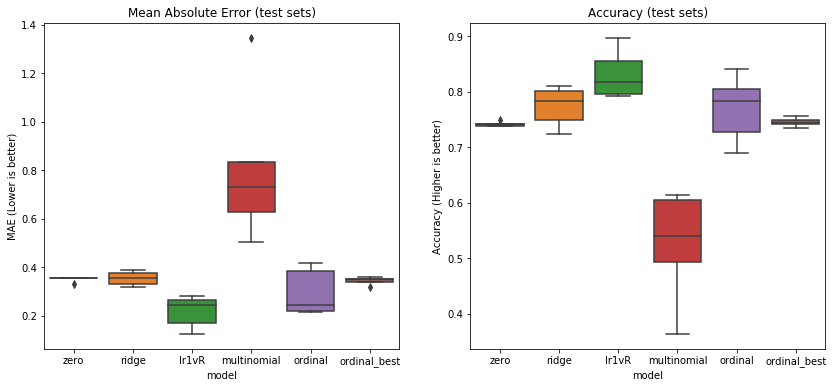

In [46]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
ax = axs[0]
sns.boxplot("variable", "value", data=pd.melt(mae_test_results.T), ax=ax)
ax.set(xlabel="model", ylabel="MAE (Lower is better)", title="Mean Absolute Error (test sets)")

ax = axs[1]
sns.boxplot("variable", "value", data=pd.melt(acc_test_results.T), ax=ax)
ax.set(xlabel="model", ylabel="Accuracy (Higher is better)", title="Accuracy (test sets)");